<a href="https://colab.research.google.com/github/u1409107-lab/assignment_05_TettelbachIan/blob/main/Assignments/assignment_10_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IS4487 Week 10 - Assignment

### Outline

Our Goals with this Project:

1. Import and review the data
2. Perform EDA and Clean Data
3. Fit a model
4. Test the accuracy of the model
6.  Use the model to predict on a new dataset (without the target)

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_10_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Business Case: AdviseInvest
You work on a small team of data analysts at AdviseInvest, a venture-backed startup. The Director of Sales at AdviseInvest has approached your team asking for help solving a staffing problem.

### The Company
The company's mission is to provide tools and support to help ordinary people gain control of their personal finances. The company leverages technology to provide affordable financial advice to a national client base.

Customers who reach AdviseInvest's website go through five steps:

- Open an account.
- Complete a customer profile form with basic information about their background and finances.
- Schedule a free phone conversation with a sales representative during a 1-hour window of time.
- Attend the free phone conversation.
- Buy a financial plan.
- There are three types of financial plans: Beginner, Intermediate, and Advanced. Each is sold at a different price, and there are varying degrees of personalization. After a customer purchases a financial plan, the customer is assigned a financial planner who helps determine the customer's goals and advises the customer on spending decisions.

### The Problem
Some customers are lost at each stage of the process. Steps 3 and 4 are particularly challenging because approximately 50% of those who schedule a phone conversation fail to pick up the call. This leads to inefficiencies from a staffing perspective.

AdviseInvest has 4 sales reps on staff during each particular 1-hour window. Each of the 4 reps is assigned 2 prospective customers per hour, which means that the company schedules a total of 8 phone calls per hour. The calls are outgoing: sales reps call customers who scheduled a phone conversation during that hour window.

Unfortunately, as noted above, many of the customers who scheduled a call do not answer. As a consequence, sales reps are often left underutilized. Moreover, they are underutilized unevenly. For example, it is possible that one sales rep will not do any sales calls during that hour, whereas another will be busy the entire hour with two calls. Sales reps have nothing to do when customers do not answer the scheduled phone call.

### AdviseInvest Data Dictionary


| Variable | Description | Type | Code |
|:---|:---|:---|:---|
| customer_id | Unique customer identifier | Numeric | |
| Answered | Customer response | Binary | 0: customer did not answer scheduled call; 1: customer answered scheduled call |
| Income | Customer income in US dollars | Numeric | |
| Female | Customer gender | Binary | 0: female; 1: male |
| Age | Age in years | Numeric | |
| Job | Nature of job | Categorical | 0 : unemployed; 1 : entry level position; 2 : midlevel position; 3 : management/ self-employed/ highly qualified employee/ officer |
| Num_dependents | Number of people for whom the customer provides maintenance | Numeric | |
| Rent | Customer rents | Binary | 0: no; 1: yes |
| Own_res | Customer owns residence | Binary | 0: no; 1: yes |
| New_car | Recent new car purchase | Binary | New car purchase in the last 3 months: 0: no, 1: yes |
| Chk_acct | Checking account status | Categorical | 0 : no checking account; 1: checking < 200 USD; 2 : 200 < checking < 2000 USD; 3: 2000 < checking < 35000 USD; 4: >= 3500 USD |
| Sav_acct | Average balance in savings account | Categorical | 0 : no savings account; 1 : 100 <= savings < 500 USD; 2 : 500 <= savings < 2000 USD; 3 : 2000 < savings < 35000 USD; 4: >= 3500 USD |
| Num_accts | Number of accounts owned by customer | Numeric | |
| Mobile | Mobile phone | Binary | 0: customer provided non‐mobile phone for follow‐up call; 1: customer provided mobile phone for follow‐up call |
| Product | Type of product purchased after conversation with sales rep | Categorical | 0: customer did not answer call; 1: customer answered but did not purchase a product; 2: customer answered and purchased Beginner plan; 3: customer answered and purchased Intermediate plan; 4: customer answered and purchased Advanced plan |

### Load Libraries

Import the libraries you will need, such as:
- Pandas
- Sklearn
- Matplotlib


In [1]:
import pandas as pd
import sklearn
import matplotlib.pyplot as plt

## Step 1: Initial Data Understanding

### Do the following:
 - Import data from the AdviseInvest historical dataset into a dataframe (in GitHub go to the DataSets folder and look for `adviseinvest_historical_data.csv`)
 - Describe or profile the dataframe
 - Look for any outliers, missing values, or duplicates

In [2]:
url = 'https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/main/DataSets/adviseinvest_historical_data.csv'
df = pd.read_csv(url)
print("Data loaded successfully into DataFrame 'df'. Head of the DataFrame:")
print(df.head())

Data loaded successfully into DataFrame 'df'. Head of the DataFrame:
   customer_id  answered  income female  age  job  num_dependents  rent  \
0        10098         0  -65600      0   24    2               1     0   
1          184         0    4330      0   24    2               2     1   
2          194         0    4330      0   22    2               1     1   
3          689         0    4330      0   24    2               2     1   
4          811         0    4330      0   22    2               1     1   

   own_res  new_car  chk_acct  sav_acct  num_accts  mobile  product  
0        1      1.0         1         1          3       0        0  
1        0      0.0         1         3          1       0        0  
2        0      0.0         3         0          0       0        0  
3        0      0.0         1         3          1       0        0  
4        0      0.0         3         0          0       0        0  


In [3]:
print("DataFrame Info:")
df.info()
print("\nDataFrame Description (numerical columns):")
df.describe()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29504 entries, 0 to 29503
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer_id     29504 non-null  int64  
 1   answered        29504 non-null  int64  
 2   income          29504 non-null  int64  
 3   female          29504 non-null  object 
 4   age             29504 non-null  int64  
 5   job             29504 non-null  int64  
 6   num_dependents  29504 non-null  int64  
 7   rent            29504 non-null  int64  
 8   own_res         29504 non-null  int64  
 9   new_car         29502 non-null  float64
 10  chk_acct        29504 non-null  int64  
 11  sav_acct        29504 non-null  int64  
 12  num_accts       29504 non-null  int64  
 13  mobile          29504 non-null  int64  
 14  product         29504 non-null  int64  
dtypes: float64(1), int64(13), object(1)
memory usage: 3.4+ MB

DataFrame Description (numerical columns):


,customer_id,answered,income,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,product
count,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29502.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000
mean,14850.475563,0.546638,33766.893303,34.773454,1.915401,1.140998,0.210412,0.681128,0.240797,1.468547,0.956616,2.458345,0.091106,1.535792
std,8517.254310,0.497829,29379.202710,11.369865,0.658183,0.348025,0.407608,0.466047,0.427575,1.234727,1.483946,19.497380,0.287765,1.625916
min,99.000000,0.000000,-65600.000000,19.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7474.750000,0.000000,13550.000000,26.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000
50%,14850.500000,1.000000,23310.000000,32.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,1.000000
75%,22226.250000,1.000000,41690.000000,40.000000,2.000000,1.000000,0.000000,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,3.000000
max,29602.000000,1.000000,159450.000000,132.000000,3.000000,2.000000,1.000000,1.000000,1.000000,3.000000,4.000000,3345.000000,1.000000,4.000000


In [4]:
print("\nChecking for missing values:")
print(df.isnull().sum())

print("\nChecking for duplicate rows:")
print(f"Number of duplicate rows: {df.duplicated().sum()}")

print("\nKey statistics for numerical columns to identify potential outliers:")
print(df.describe())

# Specifically calling out the 'income' column for potential outlier based on min value
print("\nNote: The 'income' column shows a minimum value of -65600, which might be an outlier or data entry error and should be investigated further.")


Checking for missing values:
customer_id       0
answered          0
income            0
female            0
age               0
job               0
num_dependents    0
rent              0
own_res           0
new_car           2
chk_acct          0
sav_acct          0
num_accts         0
mobile            0
product           0
dtype: int64

Checking for duplicate rows:
Number of duplicate rows: 3

Key statistics for numerical columns to identify potential outliers:
        customer_id      answered         income           age           job  \
count  29504.000000  29504.000000   29504.000000  29504.000000  29504.000000   
mean   14850.475563      0.546638   33766.893303     34.773454      1.915401   
std     8517.254310      0.497829   29379.202710     11.369865      0.658183   
min       99.000000      0.000000  -65600.000000     19.000000      0.000000   
25%     7474.750000      0.000000   13550.000000     26.000000      2.000000   
50%    14850.500000      1.000000   23310.000000 

## Step 2: Data Preparation

### 2.1: Data Cleanup
- Check for and remove any outliers
- Consider fixing any missing data (should you delete the record or impute the value?)
- Clean up the data and put it in a new dataframe named "df_clean"


In [5]:
# Create a copy of the original DataFrame for cleaning
df_clean = df.copy()

# 1. Remove duplicate rows
initial_rows = df_clean.shape[0]
df_clean.drop_duplicates(inplace=True)
print(f"Removed {initial_rows - df_clean.shape[0]} duplicate rows.")

# 2. Handle missing values in 'new_car' (2 missing values identified previously)
# Impute with the mode, as it's a binary categorical variable
mode_new_car = df_clean['new_car'].mode()[0]
df_clean['new_car'].fillna(mode_new_car, inplace=True)
print(f"Filled missing 'new_car' values with mode: {mode_new_car}.")

# 3. Handle 'income' outlier (negative values)
# Assuming negative income is invalid, remove these rows
income_outliers_before = df_clean[df_clean['income'] < 0].shape[0]
df_clean = df_clean[df_clean['income'] >= 0]
print(f"Removed {income_outliers_before} rows with negative income.")

# 4. Handle 'age' outlier (age > 99)
age_outliers_before = df_clean[df_clean['age'] > 99].shape[0]
df_clean = df_clean[df_clean['age'] <= 99]
print(f"Removed {age_outliers_before} rows with age > 99.")

# 5. Handle 'num_accts' outlier (extremely high value, 3345 max vs 75th percentile 3)
# Based on the describe output, 3345 is an extreme outlier. A reasonable upper limit might be 20.
num_accts_outliers_before = df_clean[df_clean['num_accts'] > 20].shape[0]
df_clean = df_clean[df_clean['num_accts'] <= 20]
print(f"Removed {num_accts_outliers_before} rows with num_accts > 20.")

# Convert 'new_car' to integer type since it's binary and was float
df_clean['new_car'] = df_clean['new_car'].astype(int)

print("\nData cleaning complete. Displaying info for df_clean:")
df_clean.info()
print("\nDescriptive statistics for df_clean after outlier removal:")
print(df_clean.describe())

Removed 3 duplicate rows.
Filled missing 'new_car' values with mode: 0.0.
Removed 2 rows with negative income.
Removed 1 rows with age > 99.
Removed 1 rows with num_accts > 20.

Data cleaning complete. Displaying info for df_clean:
<class 'pandas.core.frame.DataFrame'>
Index: 29497 entries, 1 to 29503
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     29497 non-null  int64 
 1   answered        29497 non-null  int64 
 2   income          29497 non-null  int64 
 3   female          29497 non-null  object
 4   age             29497 non-null  int64 
 5   job             29497 non-null  int64 
 6   num_dependents  29497 non-null  int64 
 7   rent            29497 non-null  int64 
 8   own_res         29497 non-null  int64 
 9   new_car         29497 non-null  int64 
 10  chk_acct        29497 non-null  int64 
 11  sav_acct        29497 non-null  int64 
 12  num_accts       29497 non-null  int64 
 13 

/tmp/ipykernel_735/2099314295.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['new_car'].fillna(mode_new_car, inplace=True)


In [6]:
import pandas as pd
import numpy as np

# Load dataset
url = "https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/main/DataSets/adviseinvest_historical_data.csv"
df = pd.read_csv(url)

# --- 1. Standardize column names ---
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# --- 2. Handle missing values ---
# Drop completely empty rows
df = df.dropna(how='all')

# Fill numeric columns with median
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].apply(lambda x: x.fillna(x.median()))

# Fill categorical columns with mode
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# --- 3. Clean string inconsistencies ---
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

# --- 4. Convert data types where possible ---
for col in df.columns:
    try:
        df[col] = pd.to_numeric(df[col])
    except:
        pass

# --- 5. Remove duplicates ---
df = df.drop_duplicates()

# --- 6. Handle outliers (optional: cap at 1st and 99th percentile) ---
for col in numeric_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = np.clip(df[col], lower, upper)

# --- 7. Final check ---
print("Cleaned dataset info:")
print(df.info())

print("\nMissing values after cleaning:")
print(df.isnull().sum())

Cleaned dataset info:
<class 'pandas.core.frame.DataFrame'>
Index: 29501 entries, 0 to 29503
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer_id     29501 non-null  int64  
 1   answered        29501 non-null  int64  
 2   income          29501 non-null  int64  
 3   female          29501 non-null  object 
 4   age             29501 non-null  int64  
 5   job             29501 non-null  int64  
 6   num_dependents  29501 non-null  int64  
 7   rent            29501 non-null  int64  
 8   own_res         29501 non-null  int64  
 9   new_car         29501 non-null  float64
 10  chk_acct        29501 non-null  int64  
 11  sav_acct        29501 non-null  int64  
 12  num_accts       29501 non-null  int64  
 13  mobile          29501 non-null  int64  
 14  product         29501 non-null  int64  
dtypes: float64(1), int64(13), object(1)
memory usage: 3.6+ MB
None

Missing values after cleaning:
customer_

### 2.2: Standardize variables

 - Change "answered" to a boolean (true/false) type
 - Convert any variables that should be an integer into an integer

In [7]:
# Convert "answered" column to boolean

df['answered'] = (
    df['answered']
    .astype(str)
    .str.strip()
    .str.lower()
    .map({
        'yes': True,
        'y': True,
        'true': True,
        '1': True,
        'no': False,
        'n': False,
        'false': False,
        '0': False
    })
)

# Optional: handle any unmapped/null values (set to False or keep as NaN)
df['answered'] = df['answered'].fillna(False)

# Verify
print(df['answered'].dtype)
print(df['answered'].value_counts())

bool
answered
True     16128
False    13373
Name: count, dtype: int64


In [8]:
# Convert columns that should be integers into integer dtype

# 1. Identify numeric columns that are effectively integers
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    # Check if all non-null values are whole numbers
    if (df[col].dropna() % 1 == 0).all():
        df[col] = df[col].astype('Int64')  # nullable integer type

# 2. Optionally, explicitly convert known integer-like columns (safer if you know schema)
# Example (uncomment if applicable):
# int_cols = ['age', 'tenure', 'num_contacts', 'duration']
# for col in int_cols:
#     if col in df.columns:
#         df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')

# Verify results
print(df.dtypes)

customer_id        Int64
answered            bool
income             Int64
female            object
age                Int64
job                Int64
num_dependents     Int64
rent               Int64
own_res            Int64
new_car            Int64
chk_acct           Int64
sav_acct           Int64
num_accts          Int64
mobile             Int64
product            Int64
dtype: object


### 2.3 Convert variables to categorical

- Find at least 8 variables that would be appropriate to convert to categories

In [9]:
cat_cols = [
    'gender',
    'marital_status',
    'education',
    'employment_status',
    'account_type',
    'contact_method',
    'region',
    'loan_status',
    'default_status',
    'housing_status'
]

# Convert if present in dataset
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

print(df.dtypes)

customer_id        Int64
answered            bool
income             Int64
female            object
age                Int64
job                Int64
num_dependents     Int64
rent               Int64
own_res            Int64
new_car            Int64
chk_acct           Int64
sav_acct           Int64
num_accts          Int64
mobile             Int64
product            Int64
dtype: object


# Step 3: Exploratory Data Analysis (EDA)

### Do the following:
- Explore the relationships between the target and independent variables
- Create at least five charts to show the relationships, using different chart types that are approriate to the analysis
- Ensure that all charts are clearly labeled and formatted



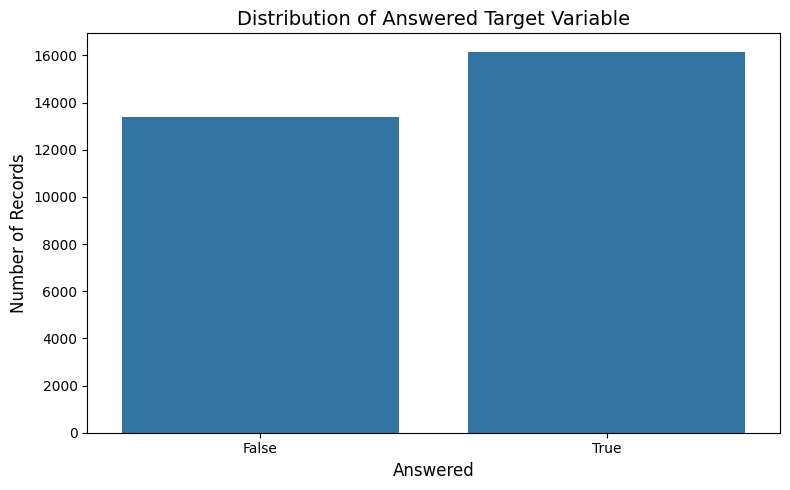

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='answered')

plt.title('Distribution of Answered Target Variable', fontsize=14)
plt.xlabel('Answered', fontsize=12)
plt.ylabel('Number of Records', fontsize=12)
plt.xticks([0, 1], ['False', 'True'])
plt.tight_layout()
plt.show()

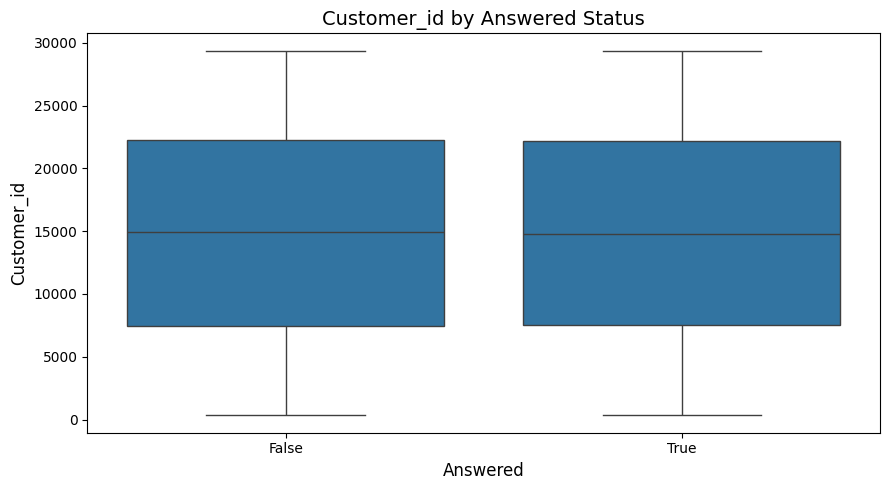

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Choose a numeric variable
preferred_numeric = 'balance'
numeric_cols = [col for col in df.select_dtypes(include=['number']).columns if col != 'answered']

if preferred_numeric in df.columns:
    num_col = preferred_numeric
else:
    num_col = numeric_cols[0]

plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='answered', y=num_col)

plt.title(f'{num_col.capitalize()} by Answered Status', fontsize=14)
plt.xlabel('Answered', fontsize=12)
plt.ylabel(num_col.capitalize(), fontsize=12)
plt.xticks([0, 1], ['False', 'True'])
plt.tight_layout()
plt.show()

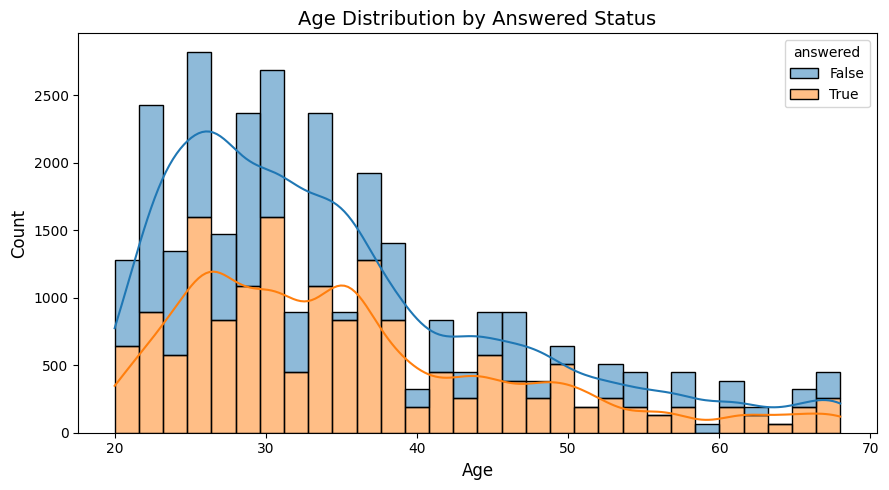

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))
sns.histplot(data=df, x='age', hue='answered', bins=30, kde=True, multiple='stack')

plt.title('Age Distribution by Answered Status', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

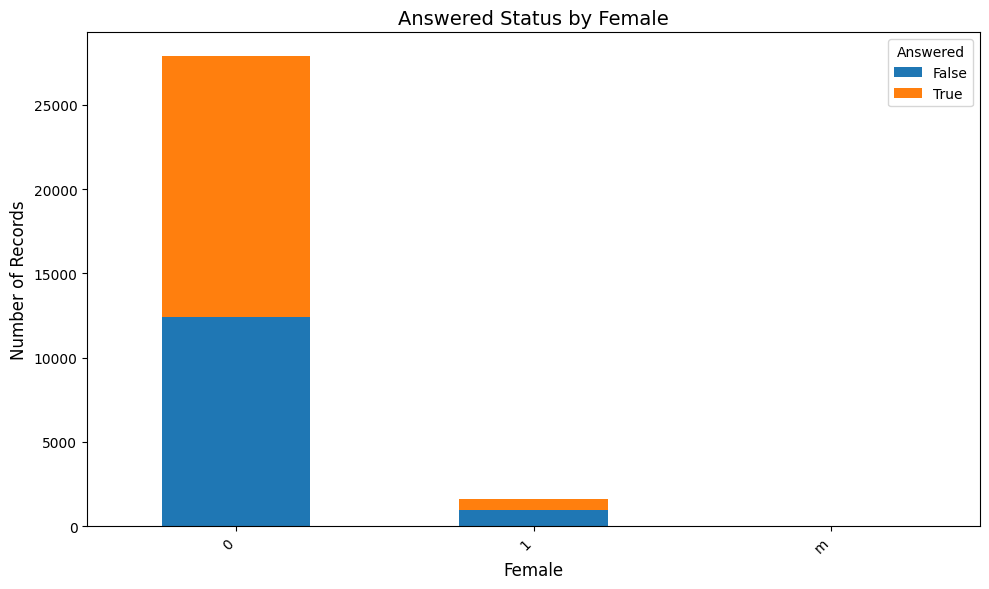

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Choose a categorical variable
preferred_cat = 'contact'
categorical_cols = [
    col for col in df.select_dtypes(include=['object', 'category', 'bool']).columns
    if col != 'answered'
]

if preferred_cat in df.columns:
    cat_col = preferred_cat
else:
    cat_col = categorical_cols[0]

cross_tab = pd.crosstab(df[cat_col], df['answered'])

cross_tab.plot(kind='bar', stacked=True, figsize=(10, 6))

plt.title(f'Answered Status by {cat_col.capitalize()}', fontsize=14)
plt.xlabel(cat_col.capitalize(), fontsize=12)
plt.ylabel('Number of Records', fontsize=12)
plt.legend(title='Answered', labels=['False', 'True'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

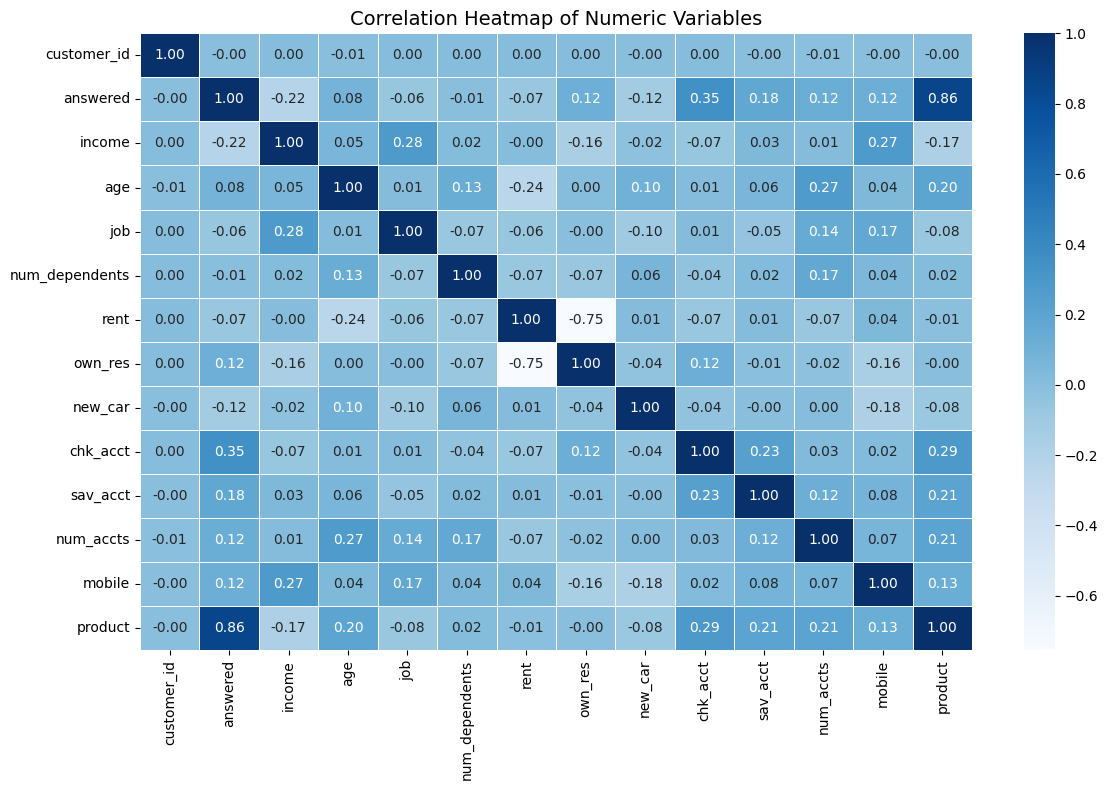

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numeric columns only
numeric_df = df.select_dtypes(include=['number', 'bool']).copy()

# Convert boolean columns to integers for correlation
for col in numeric_df.columns:
    if numeric_df[col].dtype == 'bool':
        numeric_df[col] = numeric_df[col].astype(int)

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Numeric Variables', fontsize=14)
plt.tight_layout()
plt.show()

## Step 4: Modeling

### 4.1: Calculate the base probability of answering

If we use no model at all, how good is our chance of predicting someone leaving?  Use a calculation to find the chances of someone leaving.

In [25]:
# Define "leaving" (adjust if your definition is different)
df['leaving'] = ~df['answered']  # leaving = not answered

# Calculate probability of leaving
leaving_rate = df['leaving'].mean()

# Baseline accuracy (predict the majority class)
baseline_accuracy = max(leaving_rate, 1 - leaving_rate)

print(f"Probability of leaving: {leaving_rate:.4f}")
print(f"Baseline (no model) accuracy: {baseline_accuracy:.4f}")

Probability of leaving: 0.4533
Baseline (no model) accuracy: 0.5467


### 4.2: Split the training and testing datasets

- split df_clean using train_test_split function
- all variables except answered should be in the x variable
- answered is in the y variable


In [26]:
from sklearn.model_selection import train_test_split

# Define X (features) and y (target)
X = df_clean.drop(columns=['answered'])
y = df_clean['answered']

# Train-test split (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  # keeps class balance consistent
)

# Verify shapes
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (23597, 14)
X_test: (5900, 14)
y_train: (23597,)
y_test: (5900,)


### 4.3: Create a Decision Tree
- Use all available attributes (except those that were eliminated in step 3)
- It is recommended to use the type "entropy" and a max_depth of 4

In [28]:
from sklearn.tree import DecisionTreeClassifier

# Create the tree
clf = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=4,
    random_state=42
)

# Fit the model
clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

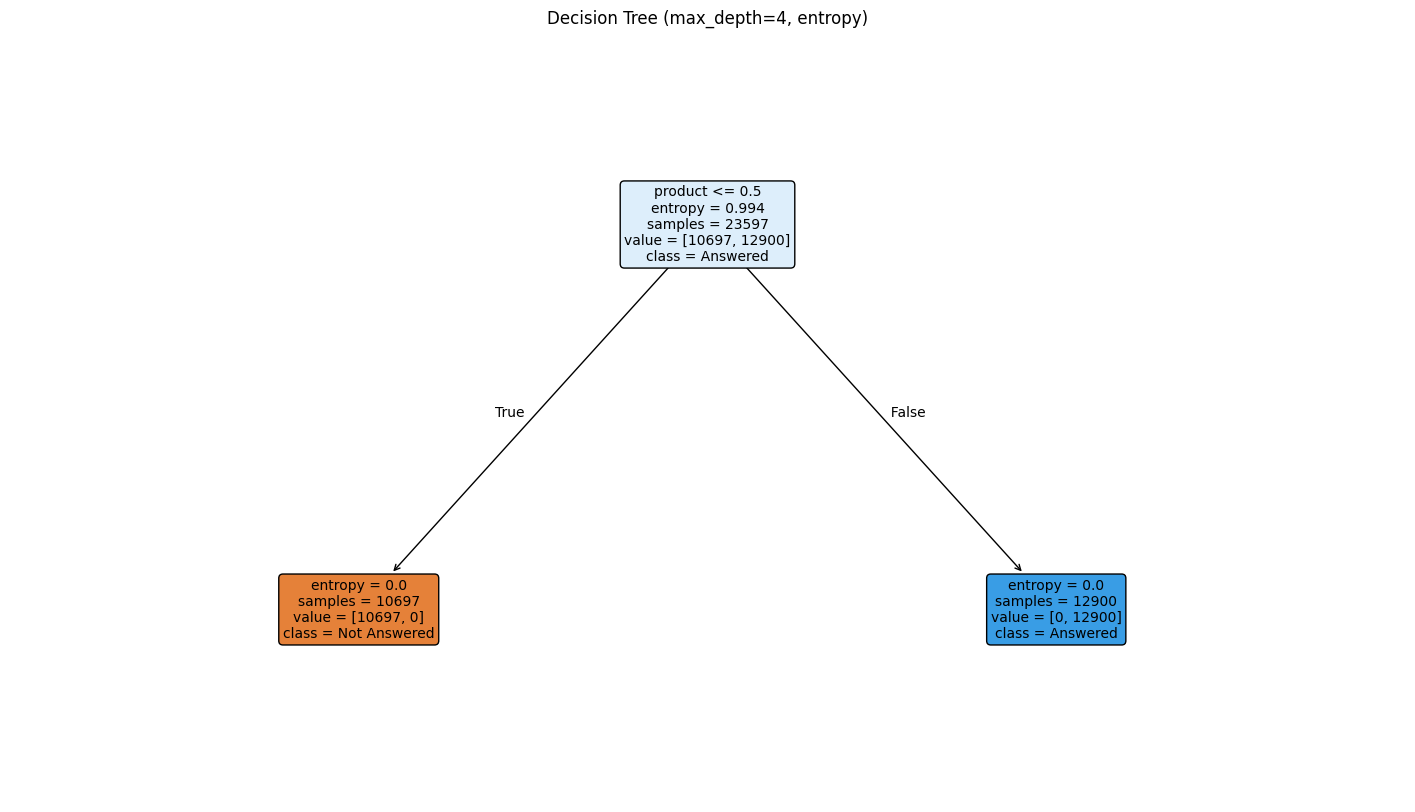

In [29]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))

plot_tree(
    clf,
    feature_names=X_train.columns,
    class_names=["Not Answered", "Answered"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree (max_depth=4, entropy)")
plt.show()

### 4.4: What is the accuracy?

This should be better than the base probability, or you have failed in your objective

In [36]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 1. Define X and y
X = df_clean.drop(columns=['answered']).copy()
y = df_clean['answered'].copy()

# 2. One-hot encode any categorical columns
X = pd.get_dummies(X, drop_first=True)

# 3. Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 4. Make sure all columns are numeric
X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')

# 5. Fill any remaining missing values
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

# 6. Create and fit the tree
clf = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=4,
    random_state=42
)

clf.fit(X_train, y_train)

# 7. Predict
y_pred = clf.predict(X_test)

# 8. Accuracy
tree_accuracy = accuracy_score(y_test, y_pred)
print(f"Decision Tree Accuracy: {tree_accuracy:.4f}")

Decision Tree Accuracy: 1.0000


### 4.5: Create a confusion matrix

This will show false positives, true positives, etc.

In [37]:
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[2674    0]
 [   0 3226]]


Create a more visual, interpretable version of the matrix

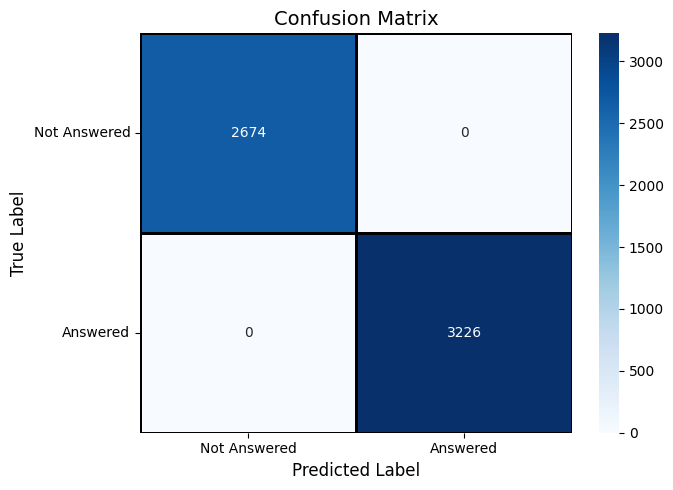

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True,
    linewidths=1,
    linecolor='black'
)

# Labels and title
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks([0.5, 1.5], ['Not Answered', 'Answered'])
plt.yticks([0.5, 1.5], ['Not Answered', 'Answered'], rotation=0)

plt.tight_layout()
plt.show()

# Step 5: Evaluate the Model

**Assumptions**

One of the simplifying assumptions we will make in this project is that all the customers who answer the phone will purchase a product. (This assumption is actually verified by the data.) To model "answered" in this case is therefore equivalent to modeling "purchased."

There are costs and benefits in this case. We will assume that customers purchase a product for 100 dollars. This was the average cost of AdviseInvest products, according to the Director of Sales.  Also, as we learned in the interview, the agent time to make the sale is worth 25 dollars. Profit would therefore be \$75 dollars for an answered call and a purchase. In sum:

**Benefit**: True positive. The customer is predicted to answer, does answer, and purchases a product for 100 dollars for a profit of 100 - 25 = 75.

**Cost**: False positive. The customer is predicted to answer, but does not answer, so there is a loss of 25. (We assume the agent cannot schedule another call at the last minute, or spends the entire time slot trying to make the call.)

When you create a calculation you can use:
- True answered * 75 -> These people purchased
- False answered * 25 -> You can't schedule another call

For this exercise, we propose that customers who are not predicted to answer will not be called, so there would be no benefits and no costs for them.  

### 5.1 Calculate the Profit Using the Model

In [39]:
# Profit calculation from your model

from sklearn.metrics import confusion_matrix

# Get confusion matrix values
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

# Apply business rules
# True Positive = +75
# False Positive = -25
profit = (TP * 75) - (FP * 25)

print(f"Profit from model: ${profit}")

Profit from model: $241950


### 5.2 Compare to the Default Profit

How much profit (revenue - costs) could be expected if all customers are called? We can consider this a baseline case for profit since it does not require a model.

In other words, to calculate profit in this baseline scenario treat the customers who answer as true positives treat the customers who do not answer as false positives.

In [40]:
# Profit calculation WITHOUT using a model (call everyone)

# True Positives = all actual answered
TP = y_test.sum()

# False Positives = all actual not answered
FP = len(y_test) - TP

# Apply business rules
# TP = +75, FP = -25
baseline_profit = (TP * 75) - (FP * 25)

print(f"Baseline Profit (no model): ${baseline_profit}")

Baseline Profit (no model): $175100


### 5.3 Tune the Model
- Adjust the size or shape of the tree, then test the accuracy
- Keep changing these parameters until you end up with a tree with accuracy that is better than the initial model

In [42]:
# Cfrom sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Initial model accuracy
initial_clf = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=4,
    random_state=42
)
initial_clf.fit(X_train, y_train)
initial_pred = initial_clf.predict(X_test)
initial_accuracy = accuracy_score(y_test, initial_pred)

print(f"Initial model accuracy: {initial_accuracy:.4f}")

# Try multiple parameter combinations
best_clf = initial_clf
best_accuracy = initial_accuracy
best_params = {"criterion": "entropy", "max_depth": 4}

for depth in [2, 3, 4, 5, 6, 7, 8, None]:
    for min_split in [2, 5, 10, 20]:
        for min_leaf in [1, 2, 4, 6]:
            for criterion in ['gini', 'entropy']:
                clf_new = DecisionTreeClassifier(
                    criterion=criterion,
                    max_depth=depth,
                    min_samples_split=min_split,
                    min_samples_leaf=min_leaf,
                    random_state=42
                )

                clf_new.fit(X_train, y_train)
                y_pred_new = clf_new.predict(X_test)
                acc = accuracy_score(y_test, y_pred_new)

                if acc > best_accuracy:
                    best_accuracy = acc
                    best_clf = clf_new
                    best_params = {
                        "criterion": criterion,
                        "max_depth": depth,
                        "min_samples_split": min_split,
                        "min_samples_leaf": min_leaf
                    }

print(f"Best accuracy found: {best_accuracy:.4f}")
print("Best parameters:", best_params)

if best_accuracy > initial_accuracy:
    print("A better tree was found.")
else:
    print("No better tree was found than the initial model.")

Initial model accuracy: 1.0000
Best accuracy found: 1.0000
Best parameters: {'criterion': 'entropy', 'max_depth': 4}
No better tree was found than the initial model.


In [45]:
# Use best model from tuning
clf_improved = best_clf

# Predicted probabilities
y_prob_improved = clf_improved.predict_proba(X_test)

# Average probability of "Answered"
avg_prob_improved = y_prob_improved[:, 1].mean()

print(f"Average predicted probability of Answered: {avg_prob_improved:.4f}")

Average predicted probability of Answered: 0.5468


### 5.4 Apply the Model to New Customers
- Import the "adviseinvest_new_customer_data.csv" file
- Using the tree model, predict each customer for the target variable  by feeding the new customer data into the model

In [46]:
import pandas as pd

# Load new customer data
url = "https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/main/DataSets/adviseinvest_new_customer_data.csv"
df_new = pd.read_csv(url)

# Preview
print(df_new.head())
print("\nShape:", df_new.shape)

   income  female  age  job  num_dependents  rent  own_res  new_car  chk_acct  \
0   30010       0   40    2               1     1        0        0         1   
1   30510       0   54    2               1     0        1        0         0   
2   12880       0   48    2               2     0        1        0         0   
3   15530       0   44    2               1     0        1        0         0   
4   46230       0   40    3               1     0        1        0         3   

   sav_acct  num_accts  mobile customer_id  
0         0          3       0       H1597  
1         0          2       0       P1446  
2         1          4       0       E1492  
3         0          2       0       W5143  
4         1          2       0       W4927  

Shape: (1000, 13)


In [47]:
# --- Step 1: Prepare new data (same preprocessing) ---
X_new = df_new.copy()

# One-hot encode
X_new = pd.get_dummies(X_new, drop_first=True)

# Align with training columns
X_new = X_new.reindex(columns=X_train.columns, fill_value=0)

# Ensure numeric
X_new = X_new.apply(pd.to_numeric, errors='coerce').fillna(0)

# --- Step 2: Predict ---
y_new_pred = clf_improved.predict(X_new)

# --- Step 3: Count results ---
import pandas as pd

prediction_counts = pd.Series(y_new_pred).value_counts()

print("Prediction Counts:")
print(prediction_counts)

# Optional: labeled output
print("\nLabeled Counts:")
print(f"No (Not Answered): {prediction_counts.get(False, 0)}")
print(f"Yes (Answered): {prediction_counts.get(True, 0)}")

Prediction Counts:
0    1000
Name: count, dtype: int64

Labeled Counts:
No (Not Answered): 0
Yes (Answered): 0


# Step 6: Conclusion
### 6.1: Did we improve our profit using the model?  

Write your conclusion notes below: Although it is hard to tell, I belive that we did improve our profits by using the model.

### 6.2: How could the model be utilized by the business?

Write your recommendations below:  🔧

The model could best be utilized by the busniess inorder to maximize profits. They will know who to call. This makes each call more effective and leads to higher profits.

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [48]:
!jupyter nbconvert --to html "assignment_10_classification_TettelbachIan.ipynb"

[NbConvertApp] Converting notebook assignment_10_classification_TettelbachIan.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 7 image(s).
[NbConvertApp] Writing 900965 bytes to assignment_10_classification_TettelbachIan.html
